In [1]:
import pandas as pd

df = pd.read_csv("student_performance_dataset.csv")
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


In [3]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score,Student_ID_S002,Student_ID_S003,Student_ID_S004,Student_ID_S005,Student_ID_S006,Student_ID_S007,...,Student_ID_S498,Student_ID_S499,Student_ID_S500,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes,Pass_Fail_Pass
0,31,68.267841,86,63,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,True,True
1,16,78.222927,73,50,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
2,21,87.525096,74,55,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,27,92.076483,99,65,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,37,98.655517,63,70,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True


In [5]:
import pandas as pd

# Step 1: Reload original dataset
df = pd.read_csv("student_performance_dataset.csv")

# Step 2: Remove Student_ID BEFORE encoding
df = df.drop("Student_ID", axis=1)

# Step 3: Convert categorical data
df = pd.get_dummies(df, drop_first=True)

# Step 4: Check result
df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes,Pass_Fail_Pass
0,31,68.267841,86,63,True,True,False,False,True,True,True
1,16,78.222927,73,50,True,False,False,True,False,False,False
2,21,87.525096,74,55,False,False,False,True,True,False,False
3,27,92.076483,99,65,False,False,False,False,False,False,True
4,37,98.655517,63,70,False,False,True,False,False,True,True


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("Final_Exam_Score", axis=1)   # input features
y = df["Final_Exam_Score"]               # target (what we predict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
predictions = model.predict(X_test)
print(predictions[:5])

[68.3818781  64.54725391 63.13939904 55.23703666 66.20241905]


In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Model Error:", mse)

Model Error: 8.586265020443575


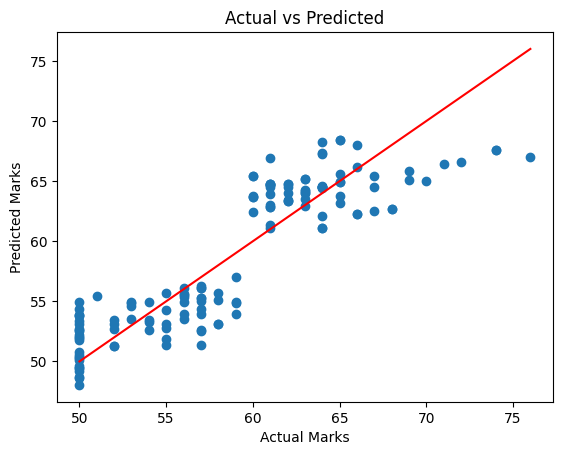

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

In [13]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

R2 Score: 0.7816056291315054
